# DCGAN

This notebook trains a **Deep Convolutional GAN (DCGAN)** on multifractal texture data stored as `.mat` files.  
Each sample contains a 2-channel (512×512) complex-valued field loaded via `scipy.io`.

**Pipeline overview:**
1. Load `.mat` files in parallel → HuggingFace `Dataset`
2. Apply an on-the-fly transform to produce 4-channel PyTorch tensors
3. Train a DCGAN (Generator + Discriminator) with BCE loss
4. Save generated textures as `.mat` and `.npy` for downstream MATLAB analysis

## 1 · Environment & Imports

In [1]:
import os
import sys
import argparse

import numpy as np
import scipy.io
from PIL import Image
from joblib import Parallel, delayed
from scipy.io import savemat

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.utils import save_image

from datasets import Dataset

print("Python:", sys.executable)
print("Version:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: /usr/bin/python3
Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True


## 2 · Configuration

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
#MAT_FOLDER  = "/scratch/janccoce/data/Workshop/"
#OUTPUT_PATH = "/scratch/janccoce/output/gan_output"
from google.colab import drive
drive.mount('/content/drive')

MAT_FOLDER  = "/content/drive/MyDrive/IMGtexture"
OUTPUT_PATH = "/content/drive/MyDrive/gan_output"

# ── Training hyperparameters ─────────────────────────────────────────────────
BATCH_SIZE    = 8 # -> 32 for the 10 000 textures
NOISE_DIM     = 100
NUM_EPOCHS    = 5 # -> 313 to take aprox 10 000 iterations as sugested
LEARNING_RATE = 2e-4
BETA1         = 0.5
NUM_WORKERS   = 8 #-> here i don't know how many i'll probably put 2

# ── Logging & checkpointing ──────────────────────────────────────────────────
SAMPLE_SIZE   = 10    # Fixed noise vectors for qualitative monitoring // probably 32 to generate new noises allways
LOG_INTERVAL  = 5    # Print losses every N batches  // probably no print here
SAVE_EPOCH    = 5     # Checkpoint every N epochs // probably 30 in case something happens

# ── Data ─────────────────────────────────────────────────────────────────────
IMAGE_KEY     = "datatmp"
BAND_INDEX    = 0
CHANNELS_IMG  = 2     # This will get automatically finded in the loading section
TARGET_SIZE   = (512, 512)

# Create output directories
for sub in ["", "samples", "checkpoints", "matlab_data"]:
    os.makedirs(os.path.join(OUTPUT_PATH, sub), exist_ok=True)

print("Output directory ready:", OUTPUT_PATH)

Mounted at /content/drive
Output directory ready: /content/drive/MyDrive/gan_output


## 3 · Data Loading

`.mat` files are loaded in parallel with `joblib` and assembled into a HuggingFace `Dataset`.  
Each sample exposes two fields:
- `image` — a PIL grayscale preview (band 0, uint8)
- `raw_data` — the full float32 array `(H, W, C)` used for training

In [3]:
def load_single_mat(mat_path, image_key="datatmp", band_index=0):
    """Load one .mat file and return a dict with a PIL preview and the raw array."""
    try:
        mat_data = scipy.io.loadmat(mat_path)
        if image_key not in mat_data:
            print(f"[WARN] Key '{image_key}' not found in {os.path.basename(mat_path)}")
            return None

        image = mat_data[image_key]           # (H, W, C)
        band  = image[:, :, band_index].astype(np.float32)

        # Scale [-1, 1] → [0, 255] for PIL preview
        band_uint8 = ((band + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
        image_pil  = Image.fromarray(band_uint8, mode="L")

        return {"image": image_pil, "raw_data": image.astype(np.float32)}

    except Exception as exc:
        print(f"[ERROR] Could not load {mat_path}: {exc}")
        return None


def load_multifractal_dataset(mat_folder, image_key="datatmp", band_index=0, n_jobs=8):
    """Scan *mat_folder* and return a HuggingFace Dataset of multifractal textures."""
    mat_files = [f for f in os.listdir(mat_folder) if f.endswith(".mat")]
    mat_paths = [os.path.join(mat_folder, f) for f in mat_files]

    data_list = Parallel(n_jobs=n_jobs)(
        delayed(load_single_mat)(path, image_key, band_index) for path in mat_paths
    )
    data_list = [item for item in data_list if item is not None]

    if not data_list:
        raise ValueError(f"No valid .mat files found in '{mat_folder}'")

    print(f"Loaded {len(data_list)} textures  |  shape: {np.array(data_list[0]['raw_data']).shape}")
    return Dataset.from_list(data_list)

In [4]:
dataset = load_multifractal_dataset(
    MAT_FOLDER, image_key=IMAGE_KEY, band_index=BAND_INDEX, n_jobs=60
)

Loaded 40 textures  |  shape: (512, 512, 2)


### 3.1 · On-the-fly Transform

The `transform` function converts each `raw_data` array `(H, W, C)` into a channels-first tensor `(C, H, W)`.  
Data are assumed to already be normalised to **[−1, 1]** (per-band normalisation is commented out below).

In [5]:
def transform(examples):
    """HuggingFace map-compatible transform: raw_data (H,W,C) → tensor (C,H,W)."""
    raws = examples["raw_data"] if isinstance(examples["raw_data"], list) else [examples["raw_data"]]
    tensors = []
    for arr in raws:
        arr = np.asarray(arr, dtype=np.float32)   # (H, W, C)
        arr = np.transpose(arr, (2, 0, 1))         # → (C, H, W)
#--------------------Here should this stay commented or no?
        # Optional per-band normalisation to [-1, 1] — uncomment if needed:
        # for c in range(arr.shape[0]):
        #     lo, hi = arr[c].min(), arr[c].max()
        #     arr[c] = (arr[c] - lo) / (hi - lo + 1e-8) * 2 - 1

        tensors.append(torch.from_numpy(arr))      # (C, H, W)
    return {"images": tensors}


dataset.set_transform(transform)

# Sanity check
sample = dataset[0]["images"]
print(f"Sample shape : {sample.shape}")
print(f"Value range  : [{sample.min():.3f}, {sample.max():.3f}]")

# Update global channels count from actual data
CHANNELS_IMG = sample.shape[0]
print(f"Channels used for training: {CHANNELS_IMG}")

Sample shape : torch.Size([2, 512, 512])
Value range  : [-1.000, 1.000]
Channels used for training: 2


## 4 · Model Architecture

### 4.1 · Discriminator

Five strided-convolution blocks (Conv → BatchNorm → LeakyReLU → Dropout) followed by a linear head with Sigmoid output.  
The flattened size is computed automatically at construction time via a forward pass with a dummy tensor.

In [6]:
class Discriminator(nn.Module):
    """Patch-style DCGAN discriminator for (C, 512, 512) inputs."""

    def __init__(self, channels_img=2, img_size=512):
        super().__init__()

        self.conv_blocks = nn.Sequential(
            self._block(channels_img,  32, batch_norm=False),
            self._block(32,  32),
            self._block(32,  64),
            self._block(64,  64),
            self._block(64, 128),
        )

        # Infer flattened size dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, channels_img, img_size, img_size)
            flat  = self.conv_blocks(dummy).view(1, -1).shape[1]
        print(f"Discriminator: flattened size = {flat}")

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 1),
            nn.Sigmoid(), #in the article they use sigmoid here but could be commented and instead of BCE as criteria
            #we could add torch.nn.BCEWithLogitsLoss that includes sigmoid inside and is optimized for this.
        )

    @staticmethod
    def _block(in_ch, out_ch, kernel_size=3, stride=2, padding=0, batch_norm=True):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, bias=not batch_norm),
            nn.BatchNorm2d(out_ch) if batch_norm else nn.Identity(),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.25),
        )

    def forward(self, x):
        return self.fc(self.conv_blocks(x))

### 4.2 · Generator

Noise `(N, 100)` → FC + BN + ReLU → reshape `(N, 8, 64, 64)` → three Upsample-Conv blocks → `(N, C, 512, 512)` with Tanh.

In [7]:
class Generator(nn.Module):
    """DCGAN generator: noise → (C, 512, 512) texture."""

    def __init__(self, channels_noise=100, channels_img=2):
        super().__init__()

        # 100 → 32768 = 8 × 64 × 64
        self.fc      = nn.Linear(channels_noise, 32_768, bias=False)
        self.fc_bn   = nn.BatchNorm1d(32_768)
        self.fc_relu = nn.ReLU(inplace=True)

        # (N, 8, 64, 64) → (N, channels_img, 512, 512)
        self.conv_layers = nn.Sequential(
            self._block(8,  64),                   # → (N,  64, 128, 128)
            self._block(64, 32),                   # → (N,  32, 256, 256)
            self._last_block(32, channels_img),    # → (N, C,  512, 512)
        )

    @staticmethod
    def _block(in_ch, out_ch):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    @staticmethod
    def _last_block(in_ch, out_ch):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        x = z.view(z.size(0), -1)                  # (N, 100)
        x = self.fc_relu(self.fc_bn(self.fc(x)))   # (N, 32768)
        x = x.view(x.size(0), 8, 64, 64)           # (N, 8, 64, 64)
        return self.conv_layers(x)                  # (N, C, 512, 512)

### 4.3 · Weight Initialisation
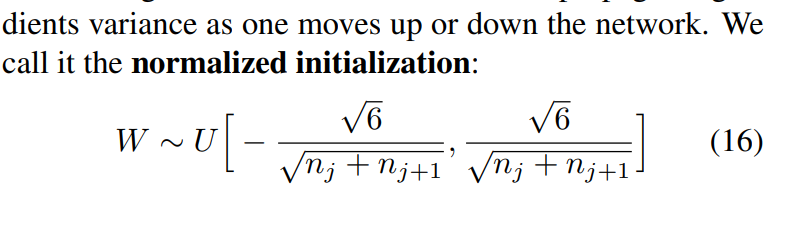


They mention this paper bud saying uniform initialization, i think is this but i'm not sure what is $n_j$, maybe i could use the simpler version that takes the interval -1/sqrt(n) to 1/sqrt(n) where n is the size of the previous layer.

Or we simply follow the DCGAN architecture that says normal centered at zero and variance 0.02, (for BatchNormalization i think is better to center at 1 i think)

In [8]:
def initialize_weights(model):
    """Apply DCGAN-style weight init: Conv/Linear ~ N(0, 0.02), BN ~ N(1, 0.02)."""
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias.data, 0)
        elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

### 4.4 · Model Instantiation

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ngpu   = torch.cuda.device_count() if device.type == "cuda" else 1
print(f"Device: {device}  |  GPUs: {ngpu}")

netG = Generator(channels_noise=NOISE_DIM, channels_img=CHANNELS_IMG).to(device)
netD = Discriminator(channels_img=CHANNELS_IMG).to(device)

if device.type == "cuda" and ngpu > 1:
    netG = nn.DataParallel(netG, list(range(ngpu)))
    netD = nn.DataParallel(netD, list(range(ngpu)))

netG.apply(initialize_weights)
netD.apply(initialize_weights)

print("\n── Generator ───────────────────────────────")
print(netG)
print("\n── Discriminator ───────────────────────────")
print(netD)

Device: cuda  |  GPUs: 1
Discriminator: flattened size = 28800

── Generator ───────────────────────────────
Generator(
  (fc): Linear(in_features=100, out_features=32768, bias=False)
  (fc_bn): BatchNorm1d(32768, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc_relu): ReLU(inplace=True)
  (conv_layers): Sequential(
    (0): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2d(8, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
     

## 5 · Training

Standard DCGAN training loop:
- **Discriminator step:** minimise `BCE(D(real), 1) + BCE(D(G(z)), 0)`
- **Generator step:** minimise `BCE(D(G(z)), 1)`

Both optimisers use **Adam with AMSGrad**.

In [10]:
def collate_fn(batch):
    """Stack 'images' tensors from a HuggingFace dataset batch."""
    return torch.stack([item["images"] for item in batch])


def train(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device        : {device}")
    print(f"Dataset size  : {len(dataset)}")
    print(f"Channels      : {args.channels_img}")

    dataloader = DataLoader(
        dataset,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=args.num_workers,
        collate_fn=collate_fn,
    )

    # Batch shape check
    batch_check = next(iter(dataloader))
    print(f"Batch shape   : {batch_check.shape}")

    # Models
    netD_ = Discriminator(channels_img=args.channels_img).to(device)
    netG_ = Generator(channels_noise=args.noise_dim, channels_img=args.channels_img).to(device)
    netD_.apply(initialize_weights)
    netG_.apply(initialize_weights)

    criterion  = nn.BCELoss()
    optimizerD = optim.Adam(netD_.parameters(), lr=args.lr, betas=(args.beta1, 0.999), amsgrad=True)
    optimizerG = optim.Adam(netG_.parameters(), lr=args.lr, betas=(args.beta1, 0.999), amsgrad=True)

    fixed_noise = torch.randn(args.sample_size, args.noise_dim, device=device)

    print("\nStarting training...")
    for epoch in range(args.num_epochs):
        for i, real_imgs in enumerate(dataloader):
            real_imgs  = real_imgs.to(device)
            batch_size = real_imgs.size(0)
            ones       = torch.ones(batch_size,  1, device=device)
            zeros      = torch.zeros(batch_size, 1, device=device)

            # ── Discriminator step ───────────────────────────────
            netD_.zero_grad()
            loss_real = criterion(netD_(real_imgs), ones)
            noise     = torch.randn(batch_size, args.noise_dim, device=device)
            fake_imgs = netG_(noise)
            loss_fake = criterion(netD_(fake_imgs.detach()), zeros)
            lossD     = loss_real + loss_fake
            lossD.backward()
            optimizerD.step()

            # ── Generator step ───────────────────────────────────
            netG_.zero_grad()
            noise     = torch.randn(batch_size, args.noise_dim, device=device)
            fake_imgs = netG_(noise)
            lossG     = criterion(netD_(fake_imgs), ones)
            lossG.backward()
            optimizerG.step()

            if i % args.log_interval == 0:
                print(
                    f"[Epoch {epoch:03d}/{args.num_epochs}] "
                    f"[Batch {i:03d}/{len(dataloader)}] "
                    f"Loss_D: {lossD.item():.4f}  Loss_G: {lossG.item():.4f}"
                )

        # ── End-of-epoch sample ──────────────────────────────────
        with torch.no_grad():
            fake_samples = netG_(fixed_noise).detach().cpu()
            fake_samples = (fake_samples + 1) / 2
            save_image(
                fake_samples[:, 0:1, :, :],
                os.path.join(args.output_dir, "samples", f"epoch_{epoch:03d}.png"),
                nrow=4, normalize=False,
            )

        # ── Checkpointing ────────────────────────────────────────
        if epoch % args.save_epoch == 0 or epoch == args.num_epochs - 1:
            ckpt = os.path.join(args.output_dir, "checkpoints")
            torch.save(netG_.state_dict(), os.path.join(ckpt, f"generator_epoch_{epoch}.pth"))
            torch.save(netD_.state_dict(), os.path.join(ckpt, f"discriminator_epoch_{epoch}.pth"))

    print("Training finished.")
    return netG_, netD_

In [ ]:
# Clean up any stale model objects before launching training
for _name in ["netD", "netG"]:
    if _name in dir():
        del globals()[_name]

args = argparse.Namespace(
    data_root    = MAT_FOLDER,
    output_dir   = OUTPUT_PATH,
    batch_size   = BATCH_SIZE,
    noise_dim    = NOISE_DIM,
    num_epochs   = NUM_EPOCHS,
    lr           = LEARNING_RATE,
    beta1        = BETA1,
    num_workers  = NUM_WORKERS,
    sample_size  = SAMPLE_SIZE,
    log_interval = LOG_INTERVAL,
    save_epoch   = SAVE_EPOCH,
    channels_img = CHANNELS_IMG,
)

netG, netD = train(args)

Device        : cpu
Dataset size  : 40
Channels      : 2


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batch shape   : torch.Size([4, 2, 512, 512])
Discriminator: flattened size = 28800

Starting training...
[Epoch 000/10] [Batch 000/10] Loss_D: 2.4149  Loss_G: 3.3527
[Epoch 001/10] [Batch 000/10] Loss_D: 1.0332  Loss_G: 0.5377
[Epoch 002/10] [Batch 000/10] Loss_D: 0.9663  Loss_G: 1.1637
[Epoch 003/10] [Batch 000/10] Loss_D: 1.1609  Loss_G: 0.7974
[Epoch 004/10] [Batch 000/10] Loss_D: 1.5856  Loss_G: 1.7513
[Epoch 005/10] [Batch 000/10] Loss_D: 0.3215  Loss_G: 0.7344
[Epoch 006/10] [Batch 000/10] Loss_D: 1.6209  Loss_G: 2.2151
[Epoch 007/10] [Batch 000/10] Loss_D: 0.3677  Loss_G: 4.0333
[Epoch 008/10] [Batch 000/10] Loss_D: 0.1260  Loss_G: 2.6194
[Epoch 009/10] [Batch 000/10] Loss_D: 0.7293  Loss_G: 3.1547
Training finished.


## 6 · Generate & Export to MATLAB

Load the latest (or a specific) generator checkpoint and export `sample_size` synthetic textures as:
- `textura_python` — shape `(N, C, H, W)` — PyTorch-native layout
- `textura_matlab` — shape `(H, W, C, N)` — MATLAB-native layout

A `.npy` backup is also saved alongside the `.mat` file.

Here should I get several files when i generate or just one that contains all the information is enough?

In [ ]:
def get_latest_epoch(checkpoint_dir):
    """Return the highest epoch number found in *checkpoint_dir*, or -1."""
    ckpts = [
        f for f in os.listdir(checkpoint_dir)
        if f.startswith("generator_epoch_") and f.endswith(".pth")
    ]
    if not ckpts:
        return -1
    epochs = [int(f.split("_")[-1].split(".")[0]) for f in ckpts]
    return max(epochs)


def generate_and_export(
    output_dir,
    noise_dim,
    channels_img,
    sample_size=40,
    epoch=None,
):
    """Load a generator checkpoint and export synthetic textures to .mat + .npy."""
    device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint_dir = os.path.join(output_dir, "checkpoints")

    if not os.path.isdir(checkpoint_dir):
        print(f"[ERROR] Checkpoint directory not found: {checkpoint_dir}")
        return

    # Resolve checkpoint path
    if epoch is None:
        epoch = get_latest_epoch(checkpoint_dir)
        if epoch < 0:
            print("[ERROR] No generator checkpoints found.")
            return

    ckpt_path = os.path.join(checkpoint_dir, f"generator_epoch_{epoch}.pth")
    if not os.path.isfile(ckpt_path):
        print(f"[ERROR] Checkpoint not found: {ckpt_path}")
        return

    print(f"Loading checkpoint: {ckpt_path}")
    gen = Generator(channels_noise=noise_dim, channels_img=channels_img).to(device)
    gen.load_state_dict(torch.load(ckpt_path, map_location=device))
    gen.eval()

    # Generate
    with torch.no_grad():
        noise        = torch.randn(sample_size, noise_dim, device=device)
        fake_samples = gen(noise).cpu().numpy()   # (N, C, H, W)

    print(f"Generated tensor shape (Python): {fake_samples.shape}")

    # Reorder to MATLAB layout: (H, W, C, N)
    fake_matlab = np.transpose(fake_samples, (2, 3, 1, 0))
    print(f"Oriented for MATLAB            : {fake_matlab.shape}")

    # Save
    out_dir  = os.path.join(output_dir, "matlab_data")
    os.makedirs(out_dir, exist_ok=True)
    mat_path = os.path.join(out_dir, f"generated_textures_epoch_{epoch}.mat")
    npy_path = os.path.join(out_dir, f"generated_textures_epoch_{epoch}.npy")

    savemat(mat_path, {
        "textura_python": fake_samples,   # (N, C, H, W)
        "textura_matlab": fake_matlab,    # (H, W, C, N)
        "metadata": {
            "batch_size" : sample_size,
            "channels"   : channels_img,
            "height"     : fake_samples.shape[2],
            "width"      : fake_samples.shape[3],
            "epoch"      : epoch,
        },
    })
    np.save(npy_path, fake_samples)

    print(f"Saved .mat  → {mat_path}")
    print(f"Saved .npy  → {npy_path}")

In [ ]:
latest_epoch = get_latest_epoch(os.path.join(OUTPUT_PATH, "checkpoints"))

if latest_epoch >= 0:
    print(f"Latest checkpoint: epoch {latest_epoch}. Generating {SAMPLE_SIZE} textures...")
    generate_and_export(
        output_dir   = OUTPUT_PATH,
        noise_dim    = NOISE_DIM,
        channels_img = CHANNELS_IMG,
        sample_size  = 40,
        epoch        = latest_epoch,
    )
else:
    print("No checkpoints found — please run training first.")

Latest checkpoint: epoch 9. Generating 10 textures...
Loading checkpoint: /content/drive/MyDrive/gan_output/checkpoints/generator_epoch_9.pth
Generated tensor shape (Python): (40, 2, 512, 512)
Oriented for MATLAB            : (512, 512, 2, 40)
Saved .mat  → /content/drive/MyDrive/gan_output/matlab_data/generated_textures_epoch_9.mat
Saved .npy  → /content/drive/MyDrive/gan_output/matlab_data/generated_textures_epoch_9.npy
